<a href="https://colab.research.google.com/github/khushi-2003/AI-projects/blob/main/CrditCardDefaultPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step - 1 : Data import

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=350)

# data (as pandas dataframes)
x = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

x.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [3]:
y.head()

,Y
0,1
1,1
2,0
3,0
4,0


In [4]:
new_cols = ['Credit_Amount','Gender','Education','Marital status','Age','Repay_Sept','Repay_Aug','Repay_July','Repay_June','Repay_May','Repay_April',
            'Bill_Sept','Bill_Aug','Bill_July','Bill__June','Bill_May','Bill_April',
           'Amount_paid_Sept','Amount_paid_Aug','Amount_paid_July','Amount_paid_June','Amount_paid_May','Amount_paid_April']

In [6]:
x.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23'],
      dtype='object')

In [7]:
x.columns = new_cols
x.columns

Index(['Credit_Amount', 'Gender', 'Education', 'Marital status', 'Age',
       'Repay_Sept', 'Repay_Aug', 'Repay_July', 'Repay_June', 'Repay_May',
       'Repay_April', 'Bill_Sept', 'Bill_Aug', 'Bill_July', 'Bill__June',
       'Bill_May', 'Bill_April', 'Amount_paid_Sept', 'Amount_paid_Aug',
       'Amount_paid_July', 'Amount_paid_June', 'Amount_paid_May',
       'Amount_paid_April'],
      dtype='object')

In [8]:
x.head()

,Credit_Amount,Gender,Education,Marital status,Age,Repay_Sept,Repay_Aug,Repay_July,Repay_June,Repay_May,...,Bill_July,Bill__June,Bill_May,Bill_April,Amount_paid_Sept,Amount_paid_Aug,Amount_paid_July,Amount_paid_June,Amount_paid_May,Amount_paid_April
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [9]:
y.value_counts()

,count
Y,
0,23364
1,6636


In [10]:
(y.value_counts()/len(y)*100)

,count
Y,
0,77.88
1,22.12


<Axes: xlabel='Y'>

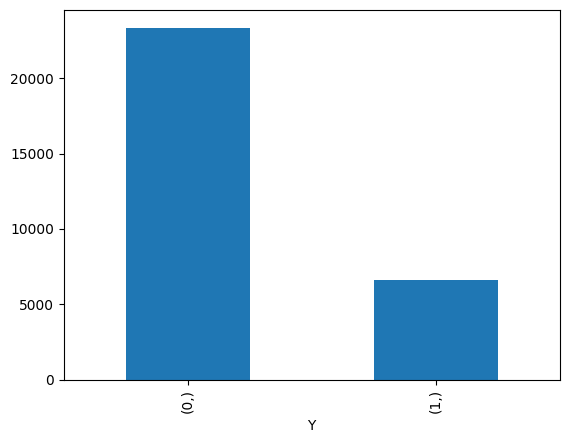

In [11]:
y.value_counts().plot(kind='bar')

The data has imbalance in target features.

In [12]:
len(y)

30000

In [14]:
x.dtypes

,0
Credit_Amount,int64
Gender,int64
Education,int64
Marital status,int64
Age,int64
Repay_Sept,int64
Repay_Aug,int64
Repay_July,int64
Repay_June,int64
Repay_May,int64


Step 2 - Data preprocessing

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

num_pipe = make_pipeline(
    SimpleImputer(strategy = 'mean'),
    StandardScaler()
).set_output(transform='pandas')

x_pre = num_pipe.fit_transform(x)
x.head()

,Credit_Amount,Gender,Education,Marital status,Age,Repay_Sept,Repay_Aug,Repay_July,Repay_June,Repay_May,...,Bill_July,Bill__June,Bill_May,Bill_April,Amount_paid_Sept,Amount_paid_Aug,Amount_paid_July,Amount_paid_June,Amount_paid_May,Amount_paid_April
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


Step 3 - Splitting the data into training and testing.

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_pre,y,train_size = 0.7,random_state=21)

Step 4 - Balance the target samples using SMOTE

In [16]:
pip install imblearn

In [18]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_sample,y_sample = smote.fit_resample(x_train,y_train)

In [21]:
y_sample.value_counts()

,count
Y,
0,16364
1,16364


Step 5 - Build Neural network.

In [22]:
from keras.models import Sequential
from keras.layers import Input,Dense

In [23]:
#initializing the model
model = Sequential()

#input layer
model.add(Input(shape=(x_train.shape[1],)))

#hidden layer 1
model.add(Dense(units=64,activation='relu'))

#hidden layer 2
model.add(Dense(units=32,activation='relu'))

#output layer
model.add(Dense(units=1,activation='sigmoid'))



In [24]:
model.compile(optimizer='adam',loss = 'binary_crossentropy',metrics = ['accuracy'])

In [26]:
nn = model.fit(x_sample,y_sample,validation_split =0.2,epochs=50)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7667 - loss: 0.4839 - val_accuracy: 0.6624 - val_loss: 0.6104
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7633 - loss: 0.4871 - val_accuracy: 0.5755 - val_loss: 0.7255
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7655 - loss: 0.4823 - val_accuracy: 0.5503 - val_loss: 0.7692
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7701 - loss: 0.4783 - val_accuracy: 0.5649 - val_loss: 0.7507
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7755 - loss: 0.4684 - val_accuracy: 0.6334 - val_loss: 0.6383
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7759 - loss: 0.4687 - val_accuracy: 0.6028 - val_loss: 0.6702
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7701 - loss: 0.4735 - val_accuracy: 0.6158 - val_loss: 0.6627
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7696 - loss: 0.4747 - val_accuracy: 0.

Step 6 - Check Learning curve

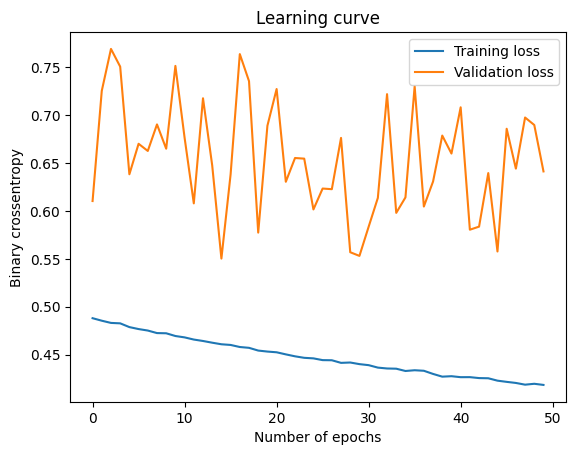

In [27]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training loss')
plt.plot(nn.history['val_loss'],label='Validation loss')
plt.xlabel('Number of epochs')
plt.ylabel('Binary crossentropy')
plt.title('Learning curve')
plt.legend()

In [28]:
model.evaluate(x_test,y_test)

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7678 - loss: 0.5574


[0.5563011169433594, 0.7681111097335815]

In [30]:
y_preds = model.predict(x_test)
y_preds[:10]

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.5509962 ],
       [0.77571464],
       [0.07901514],
       [0.01197579],
       [0.32682112],
       [0.3019413 ],
       [0.6817689 ],
       [0.11190397],
       [0.5886247 ],
       [0.00497006]], dtype=float32)

In [32]:
y_test.head()

,Y
6677,0
20672,1
19682,0
23589,0
16352,1


In [35]:
y_preds_new = []
for i in y_preds:
  if(i > 0.5):
    y_preds_new.append(1)
  else:
    y_preds_new.append(0)
y_preds_new[:10]

[1, 1, 0, 0, 0, 0, 1, 0, 1, 0]

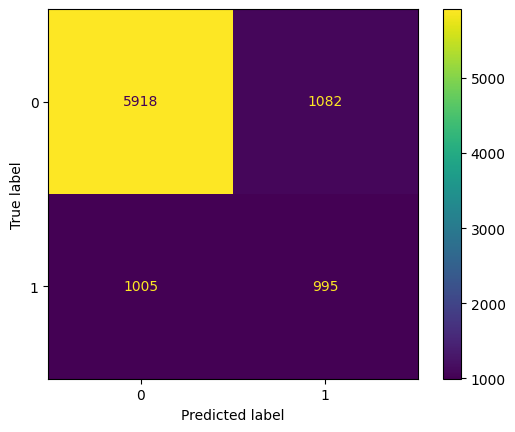

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_preds_new)

In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_preds_new))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      7000
           1       0.48      0.50      0.49      2000

    accuracy                           0.77      9000
   macro avg       0.67      0.67      0.67      9000
weighted avg       0.77      0.77      0.77      9000

